Анализ продаж интернет-магазина Olist (Бразилия)
Датасет: Olist Brazilian E-Commerce — данные о заказах, товарах и клиентах за сентябрь 2016 – октябрь 2018.
Скачать можно здесь: (https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). Поместите файлы в папку data/ перед запуском.

Задача: разобраться, как менялась выручка во времени, какие категории товаров и регионы дают основной вклад, и есть ли в данных аномалии, которые стоит изучить отдельно.

Основные выводы:
Выручка растёт за счёт роста числа заказов, а не среднего чека — он стабилен на уровне ~140 BRL.
Топ-5 категорий дают около 40% всей выручки — есть риск зависимости от узкого ассортимента.
Штат São Paulo (SP) формирует более трети выручки, несколько штатов (RR, AP, AC) приносят менее 0,2% каждый.
В данных есть аномально дорогие заказы (выше 275 BRL по IQR), которые стоит изучить отдельно.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


In [15]:

orders = pd.read_csv('data/olist_orders_dataset.csv')
items = pd.read_csv('data/olist_order_items_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')

orders = pd.DataFrame(orders)
items = pd.DataFrame(items)
customers = pd.DataFrame(customers)
products = pd.DataFrame(products)

In [20]:
display('Описание таблицы заказов:')
display('Кол-во заказов: ', orders['order_id'].count())
display('Начало периода: ', orders['order_purchase_timestamp'].min())
display('Конец периода: ', orders['order_purchase_timestamp'].max())
display('Доля пропусков в каждой колонке: ', orders.isna().sum()/len(orders))
display('Статусы заказов: ', orders['order_status'].unique())
display('Распределение по статусам: ', orders['order_status'].value_counts(normalize=True))

'Описание таблицы заказов:'

'Кол-во заказов: '

np.int64(99441)

'Начало периода: '

'2016-09-04 21:15:19'

...

order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.001609
order_delivered_carrier_date     0.017930
order_delivered_customer_date    0.029817
order_estimated_delivery_date    0.000000
dtype: float64

'Статусы заказов: '

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

'Распределение по статусам: '

order_status
delivered      0.970203
shipped        0.011132
canceled       0.006285
unavailable    0.006124
invoiced       0.003158
processing     0.003027
created        0.000050
approved       0.000020
Name: proportion, dtype: float64

Кол-во заказов: 99441 за период с 4 сентября 2016го по 17 октября 2018го;
Доля пропусков в каждой колонке: 
order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.001609
order_delivered_carrier_date     0.017930
order_delivered_customer_date    0.029817
order_estimated_delivery_date    0.000000
Статусы заказов:  ['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']
 Распределение по статусам: 
order_status
delivered      0.970203
shipped        0.011132
canceled       0.006285
unavailable    0.006124
invoiced       0.003158
processing     0.003027
created        0.000050
approved       0.000020
 

In [ ]:
#Фильтруем заказы со статусом 'delivered'
delivered_orders = orders[orders['order_status'] == 'delivered']

#объединяем таблицы orders, items, products, customers, чтобы получить сводные по признакам
order_items = items.merge(delivered_orders, on = 'order_id', how = 'inner', validate = 'many_to_one')
#Проверка значений revenue перед объединением таблиц
revenue = order_items['price'].sum()

#Сразу добавляем столбец с месяцем и годом для группировки по периодам
order_items['month'] = pd.to_datetime(order_items['order_approved_at']).dt.to_period('M')
order_items_product = order_items.merge(products[['product_id','product_category_name']], on = 'product_id', how='left', validate= 'many_to_one')
full_data = order_items_product.merge(customers[['customer_id', 'customer_state']], on = 'customer_id', how= 'left', validate = 'many_to_one')

#Проверка значений revenue после объединения таблиц
revenue2 = full_data['price'].sum()
display('Доходы до объединения таблиц', revenue)
display('Доходы после объединения таблиц', revenue2)
display('Доходы до и после равны? ', revenue == revenue2)

#Составляем сводные в разрезе различных признаков
#Сводная в разрезе месяцев
gr_by_month = full_data.groupby('month').agg(revenue = ('price', 'sum')
, order_cnt = ('order_id', 'nunique')
, unique_customers = ('customer_id', 'nunique')).reset_index().sort_values('month')
gr_by_month['AOV'] = (gr_by_month['revenue'] / gr_by_month['order_cnt'])
gr_by_month['growth'] = (gr_by_month['revenue'].pct_change() *100)
gr_by_month['cumulative'] = gr_by_month['revenue'].cumsum()
display('Динамика доходов по месяцам:', gr_by_month[['month','revenue']], sep = '\n')
display('Максимальное значение выручки: ', gr_by_month[['month','revenue']]['revenue'].max())

Доходы до объединения таблиц 13221498.110000001
Доходы после объединения таблиц 13221498.110000001
Доходы до и после равны?  True
Динамика доходов по месяцам:
      month    revenue
0   2016-09     134.97
1   2016-10   40325.11
2   2016-12      10.90
3   2017-01  106888.10
4   2017-02  234163.38
5   2017-03  355372.21
6   2017-04  338207.85
7   2017-05  490696.21
8   2017-06  425825.55
9   2017-07  476556.89
10  2017-08  555061.46
11  2017-09  597240.93
12  2017-10  652987.87
13  2017-11  972604.18
14  2017-12  747390.69
15  2018-01  917667.20
16  2018-02  819355.27
17  2018-03  963604.25
18  2018-04  953526.94
19  2018-05  999867.28
20  2018-06  859882.79
21  2018-07  849818.11
22  2018-08  862639.54
Максимальное значение выручки:  999867.28


In [ ]:
# Сводная доходов по категориям товаров
gr_by_category = (full_data.groupby('product_category_name')
.agg(revenue = ('price', 'sum'), orders_cnt = ('order_id', 'nunique'), customer_cnt = ('customer_id','nunique'))
.reset_index().sort_values('revenue', ascending = False))
gr_by_category['pct'] = gr_by_category['revenue']/gr_by_category['revenue'].sum() * 100
display('Число заказов по каждой категории', gr_by_category[['product_category_name', 'orders_cnt']].head(10), sep = '\n')


#Сводная доходов по штатам
gr_by_state = full_data.groupby('customer_state').agg(count_orders = ('order_id', 'nunique'), revenue = ('price', 'sum')).reset_index().sort_values('count_orders', ascending = False)
gr_by_state['pct'] = gr_by_state['revenue']/gr_by_state['revenue'].sum() * 100
display('Топ-5 штатов по кол-ву заказов:', gr_by_state[['customer_state', 'count_orders']].head(5), sep = '\n')
display('Топ-5 штатов по сумме заказов:', gr_by_state[['customer_state', 'revenue', 'pct']].sort_values('revenue', ascending=False).head(5), sep = '\n')



Число заказов по каждой категории
     product_category_name  orders_cnt
11            beleza_saude        8647
66      relogios_presentes        5495
13         cama_mesa_banho        9272
32           esporte_lazer        7530
44  informatica_acessorios        6530
54        moveis_decoracao        6307
72   utilidades_domesticas        5743
26              cool_stuff        3559
8               automotivo        3810
12              brinquedos        3804

Топ-5 штатов по кол-ву заказов:
   customer_state  count_orders
25             SP         40501
18             RJ         12350
10             MG         11354
22             RS          5345
17             PR          4923
Топ-5 штатов по сумме заказов:
   customer_state     revenue        pct
25             SP  5067633.16  38.328736
18             RJ  1759651.13  13.309015
10             MG  1552481.83  11.742102
22             RS   728897.47   5.512972
17             PR   666063.51   5.037731


In [ ]:
display('Топ самых недоходных штатов по сумме заказов:', gr_by_state[['customer_state', 'revenue', 'pct']].sort_values('revenue', ascending=True).head(5), sep = '\n')
display(gr_by_state.describe())
display('Топ-5 категорий по сумме заказов:', gr_by_category[['product_category_name', 'revenue', 'pct']].head(5), sep = '\n')


Топ самых недоходных штатов по сумме заказов:
   customer_state   revenue       pct
21             RR   7057.47  0.053379
3              AP  13374.81  0.101160
0              AC  15930.97  0.120493
2              AM  22155.84  0.167574
20             RO  45682.76  0.345519
       count_orders       revenue        pct
count     27.000000  2.700000e+01  27.000000
mean    3573.259259  4.896851e+05   3.703704
std     8021.983682  1.012662e+06   7.659206
min       41.000000  7.057470e+03   0.053379
25%      366.000000  6.771496e+04   0.512158
50%      886.000000  1.521916e+05   1.151092
75%     2668.000000  3.950413e+05   2.987871
max    40501.000000  5.067633e+06  38.328736
Топ-5 категорий по сумме заказов:
     product_category_name     revenue       pct
11            beleza_saude  1233131.72  9.448727
66      relogios_presentes  1166176.98  8.935694
13         cama_mesa_banho  1023434.76  7.841948
32           esporte_lazer   954852.55  7.316445
44  informatica_acessorios   888724.61  6.

In [ ]:
display('Показатели среднего чека и накопительной суммы по месяцам:', gr_by_month[['month','revenue', 'order_cnt', 'AOV',  'cumulative']], sep = '\n')

Показатели среднего чека и накопительной суммы по месяцам:
      month    revenue  order_cnt         AOV   cumulative
0   2016-09     134.97          1  134.970000       134.97
1   2016-10   40325.11        265  152.170226     40460.08
2   2016-12      10.90          1   10.900000     40470.98
3   2017-01  106888.10        715  149.493846    147359.08
4   2017-02  234163.38       1638  142.956886    381522.46
5   2017-03  355372.21       2554  139.143387    736894.67
6   2017-04  338207.85       2278  148.467011   1075102.52
7   2017-05  490696.21       3548  138.302201   1565798.73
8   2017-06  425825.55       3143  135.483789   1991624.28
9   2017-07  476556.89       3828  124.492396   2468181.17
10  2017-08  555061.46       4217  131.624724   3023242.63
11  2017-09  597240.93       4170  143.223245   3620483.56
12  2017-10  652987.87       4441  147.036224   4273471.43
13  2017-11  972604.18       7150  136.028557   5246075.61
14  2017-12  747390.69       5675  131.698800   5993466.

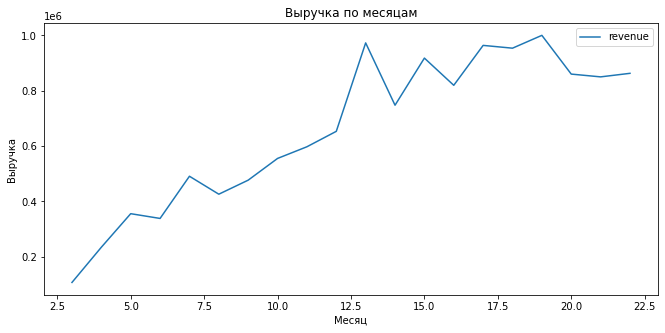

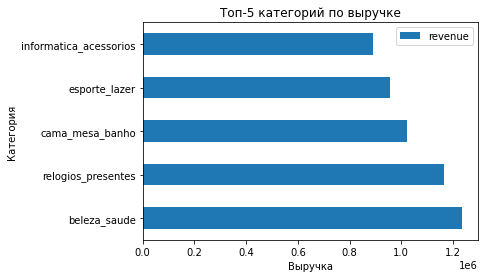

In [ ]:
#графики

gr_by_month[['month', 'revenue']].iloc[3:].plot(figsize = (11, 5) , title = 'Выручка по месяцам')
plt.xlabel('Месяц'); plt.ylabel('Выручка'); plt.show()

top_5 = gr_by_category[['product_category_name', 'revenue']].head(5).set_index('product_category_name')
top_5.plot(kind = 'barh', title = 'Топ-5 категорий по выручке')
plt.xlabel('Выручка'); plt.ylabel('Категория'); plt.show()
plt.show()


In [ ]:
display('Описание средних, медианы и квартилей', full_data['price'].describe(), sep = '\n')
display('Доля смещения средней по отношению к медиане: ', round(full_data['price'].mean()/full_data['price'].median(),2))
Q1 = full_data['price'].quantile(0.25)
Q3 = full_data['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

display('Допустимое нижнее значение стоимости заказа =', round(lower,2))
display('Допустимое верхнее значение стоимости заказа =', round(upper,2))


Описание средних, медианы и квартилей
count    110197.000000
mean        119.980563
std         182.299446
min           0.850000
25%          39.900000
50%          74.900000
75%         134.170000
max        6735.000000
Name: price, dtype: float64
Доля смещения средней по отношению к медиане:  1.6
Допустимое нижнее значение стоимости заказа = -101.5
Допустимое верхнее значение стоимости заказа = 275.57


Детальные выводы:

1. Динамика выручки по месяцам:
В сентябре, ноябре и декабре 2016го года видно, что присутствуют неполные данные, поэтому рекомендую начать исследования начиная с января 2017го, потому что начиная с этого периода, данные выглядят адекватно.

Есть устойчивая тенденция роста выручки, с небольшими колебаниями вниз. Средний чек стабилен весь период на уровне ~140 BRL, значит рост выручки — это рост числа заказов, а не удорожание корзины. Стоит проверить, можно ли поднять AOV через допродажи.

2. Средний доход (119.98 BRL) по всем заказам по сравнению с медианой (74.9 BRL) сильно завышен в 1.6 раза, это может происходить из-за единичных аномально дорогих заказов. Это видно по величине максимального заказа. 

3. Определим аномально высокие значения, которые по расчетам превышают 275.57 BRL, в отдельную группу и будем изучать их отдельно.
 
4. Топ-5 категорий по сумме заказов составляет ~ 40 % всей доходности, есть
риск зависимости от узкого ассортимента, стоит проверить концентрацию

5. Лидирующие позиции по выручке является SP, RJ, MG. Эти штаты занимают весомую долю выручки компании: SP ~ 38%, RJ ~ 13%, MG ~ 12%. Таким образом они занимают 63 % рынка, в то время как штаты RR, AP, AC, AM приносят менее 
0.2% каждый. Совокупный доход находится ниже медианного уровня. Стоит проверить, когда мы вышли на рынок это штатов, и целесообразность вложений в продажи по этим географиечским направлениям.